# Set-up

In [ ]:
import os
from google.colab import userdata

# Get the token from the Secrets pane
github_token = userdata.get('Crecerelle-GitHub-Access')

# Set it as an environment variable for pip
os.environ['Crecerelle-GitHub-Access'] = github_token

# @markdown **Crecerelle:** Install the library from GitHub
!pip install git+https://{os.environ['Crecerelle-GitHub-Access']}@github.com/Hollfelder-Lab/crecerelle.git

In [ ]:
# @markdown **Directory structure:** Set-up the directory structure to store the results of Crecerelle. We recommend connecting to your Google Drive. Otherwise, the directories will be created only temporarily in Colab. If you have already set-up the directory structure from a previous analysis, the existing directories will not be overwritten but only the new ones added.

connect_google_drive = True # @param {type:"boolean"}

if connect_google_drive:
    from google.colab import drive
    drive.mount('/content/drive')

    root_directory = "/content/drive/My Drive"
else:
    root_directory = "/content"

The following directory structure is then created:
```text
root_directory/
└── crecerelle_results/
    ├── data/
    │   └── <dataset_name>/  *(optional)*
    ├── figures/
    │   └── <dataset_name>/  *(optional)*
    └── models/
        ├── scGETUVI/
        ├── scTUVI/
        └── scVI/

The gene expression and transcript usage data along with the gene annotation must be uploaded in the according folder crecerelle_results/data/dataset_name.

In [ ]:
import os

# @markdown **Dataset name:** Define the dataset name
dataset_name = "tabulaMuris" # @param

# Set-up the directory structure
setup_crecerelle(root_directory, dataset_name=dataset_name)

# @markdown The working directory is then set to "./crecerelle_results"
if os.path.basename(os.path.normpath(os.getcwd())) != "crecerelle_results":
    os.chdir("drive/My Drive/crecerelle_results")

# Print the working directory
print(f"The working directory is set to: {os.getcwd()}")

In [ ]:
!pip install anndata
!pip install igraph
!pip install leidenalg
!pip install scanpy
!pip install setuptools
!pip install ClustAssessPy
!pip install gdown
!pip install plotnine
!pip install wheel
!pip install umap-learn
!pip install scikit-misc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.3/172.3 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 92.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 24.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 38.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of louvain to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 4.3 MB/s eta 

In [ ]:
# @markdown **Imports:** modules from PyTorch, Numpy, Scanpy, ClustAssess amongst others are imported together with the crecerelle modules necessary for pre-processing gene expression and transcript usage data

import warnings
import pandas as pd
import anndata as ad
import scanpy as sc
import scanpy.external as sce
import ClustAssessPy as ca
from scipy.io import mmread
import numpy as np
import matplotlib.pyplot as plt

from plotnine import ggplot, ggsave

from crecerelle.utils import intron_names_2_integers, compute_psi, remove_cell_genes, GeneExpressionTranscriptUsageDataset, split_adata_dataset

from crecerelle.training_utils import random_dataset_split

In [ ]:
# @markdown **Specify settings:** These are the general settings for keys to be defined. They are stored in a dictionary called settings. The dataset_name key is already saved in it.

# @markdown Key of Anndata object specifiying the cell type
settings_cell_type_key = "cell_ontology_class" # @param

# @markdown  Cell types of dataset given
settings_cell_types = TABULA_MURIS_CELL_TYPES # @param

# @markdown Abbreviations of cell types
settings_cell_type_abbreviations = TABULA_MURIS_CELL_TYPE_ABBREVIATION_DICT # @param

# @markdown Organisational entity of cell groups (e.g. tissue)
settings_cell_type_groups_key = "tissue" # @param

# @markdown Name of gene annotation file
settings_gene_annotation = "Mus_musculus.GRCm38.102.chr.gtf.gz" # @param

settings = {
    "dataset_name": dataset_name, # Name of dataset
    "cell_type_key": settings_cell_type_key, # Key of Anndata object specifiying the cell type
    "cell_types": settings_cell_types, # Cell types of dataset given
    "cell_type_abbreviations": settings_cell_type_abbreviations, # Abbreviations of cell types
    "cell_type_groups_key": settings_cell_type_groups_key, # Organisational entity of cell groups (e.g. tissue)
    "gene_annotation": settings_gene_annotation
}

In [ ]:
# @markdown All data files must be stored here and the resulting new data will also be stored here.
path2data = "./data/" + settings["dataset_name"] + "/"

print(f"The data files will be stored in: {path2data}")

In [ ]:
# @markdown Ensure the Anndata objects of the gene expression and transcript usage data are uploaded in "./crecerelle_results/data/dataset_name" *(optional)*.

# @markdown Name the .h5ad files containing the gene expression and splicing data
gene_expression_file = "adata_exp.h5ad" # @param {type:"string"}
splicing_file = "adata_spl.h5ad" # @param {type:"string"}

# Loading of raw gene expression data

In [ ]:
# @markdown Load the AnnData file containing the raw gene expression counts
adata_GE = ad.read_h5ad(path2data + gene_expression_file)

if settings["dataset_name"] == "tabulaMuris":
    # Switch gene name and gene ID
    adata_GE.var["gene_id"] = adata_GE.var_names.copy()
    adata_GE.var["gene_name"] = gene_names
    adata_GE.var.index = adata_GE.var["gene_name"]
    adata_GE.var_names = adata_GE.var.index
    del adata_GE.var["gene_name"]

print(f"Following AnnData file containing the raw gene expression data has been loaded: \n {adata_GE}")


## Archive

In [ ]:
# Path to raw data and gene annotation
path2dataset = "./data/" + dataset_name
gene_annotation = "./data/Mus_musculus.GRCm38.102.chr.gtf.gz"
cellxgene = "adata_cellxgene.h5ad"
expression = "adata_exp.h5ad"
splicing = "adata_spl.h5ad"

In [ ]:
# Analysis of gene ID names (compare exp and cellxgene)
adata_GE = ad.read_h5ad(path2dataset + expression)
adata_cellxgene = ad.read_h5ad(path2dataset + cellxgene)
exp_gene_ids = adata_GE.var_names.to_list()
cellxgene_gene_ids = adata_cellxgene.var["gene_id"].to_list()
cellxgene_gene_names = adata_cellxgene.var_names.to_list()
num_cellxgene_gene_names = np.argwhere(np.char.find(np.array(cellxgene_gene_names), "_chr") != -1)[0].item() # 27348 for Tabula Muris, xx for mouse cortex BICCN
print(f"Gene IDs of Cell x Gene and Expression file are identical: {cellxgene_gene_ids[0:num_cellxgene_gene_names] == exp_gene_ids}")
gene_names = cellxgene_gene_names[0:num_cellxgene_gene_names]
print(gene_names)

# Switch gene name and gene ID
adata_GE.var["gene_id"] = adata_GE.var_names.copy()
adata_GE.var["gene_name"] = gene_names
adata_GE.var.index = adata_GE.var["gene_name"]
adata_GE.var_names = adata_GE.var.index
del adata_GE.var["gene_name"]
adata_GE


In [ ]:
# Delete adata_cellxgene
import gc
del adata_cellxgene
gc.collect()

In [ ]:
adata_GE.obs

In [ ]:
adata_GE.var

,gene_id
gene_name,
Xkr4,ENSMUSG00000051951
Gm37180,ENSMUSG00000103377
Gm37363,ENSMUSG00000104017
Gm37686,ENSMUSG00000103025
Gm37329,ENSMUSG00000103201
...,...
mt-Nd6,ENSMUSG00000064368
mt-Te,ENSMUSG00000064369
mt-Cytb,ENSMUSG00000064370


# Quality controls of raw data

The following code carries out quality controls of the raw gene expression data

In [ ]:
# @markdown Determine the mitochondrial, ribosomoal, and hemoglobin genes present. Note, that dependent on mouse or human data the abbreviations might differ. The abbreviations here are for mouse.
# mitochondrial genes, "MT-" for human, "mt-" for mouse
adata_GE.var["mt"] = adata_GE.var_names.str.startswith("mt-")
# ribosomal genes
adata_GE.var["ribo"] = adata_GE.var_names.str.startswith(("Rps", "Rpl"))
# hemoglobin genes
adata_GE.var["hb"] = adata_GE.var_names.str.contains("^hb[^(P)]")

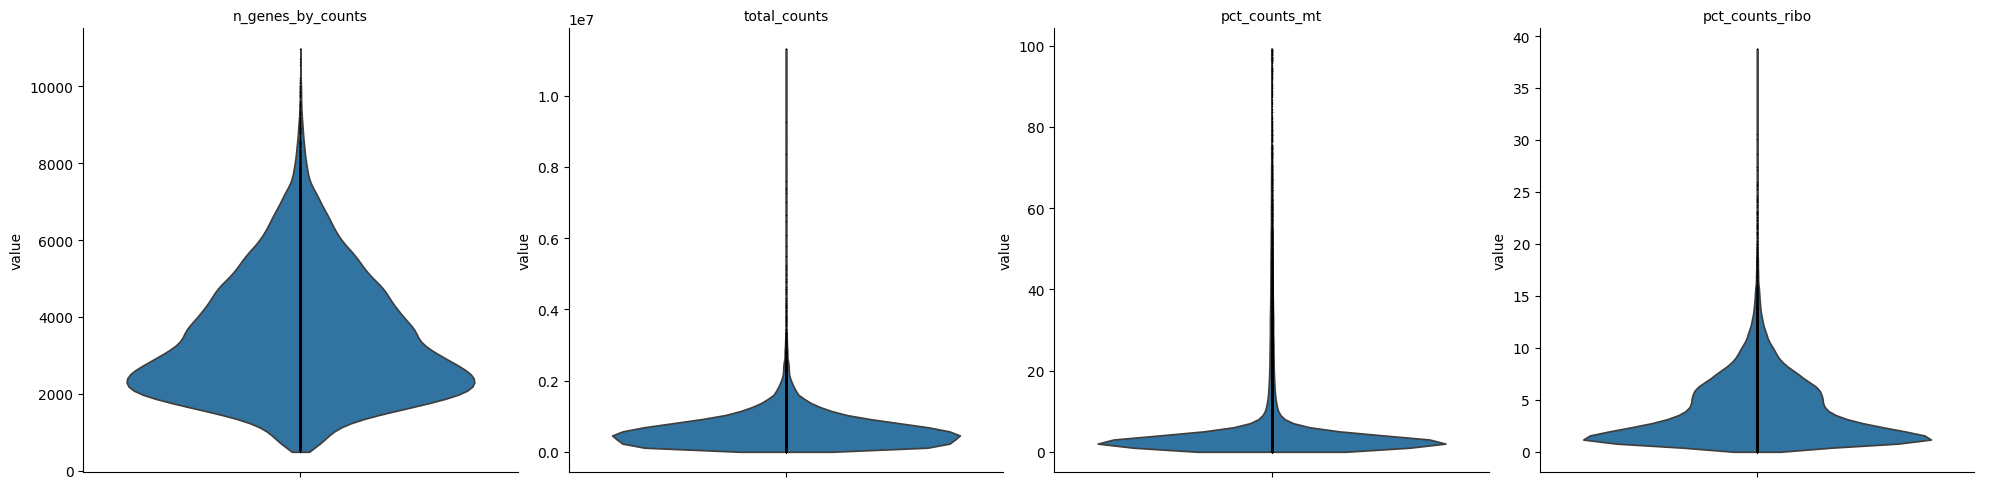

In [ ]:
# @markdown Plot the QC metrics (number of genes by counts per cell, total counts per cell, percentage counts of mitochondrial genes per cell, percentage counts of ribosomoal genes per cell)
sc.pp.calculate_qc_metrics(
    adata_GE, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

sc.pl.violin(
    adata_GE,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo"],
    jitter=0,
    multi_panel=True,
    save="_" + dataset_name[:-1] + "_full_data_raw.png"
)

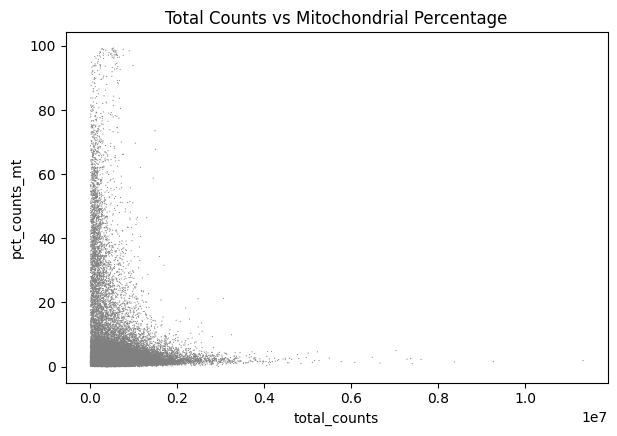

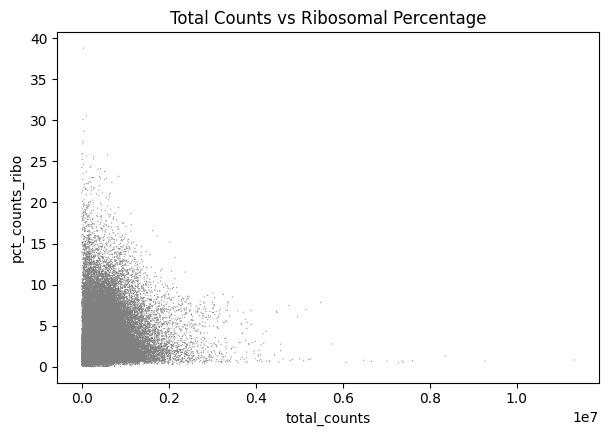

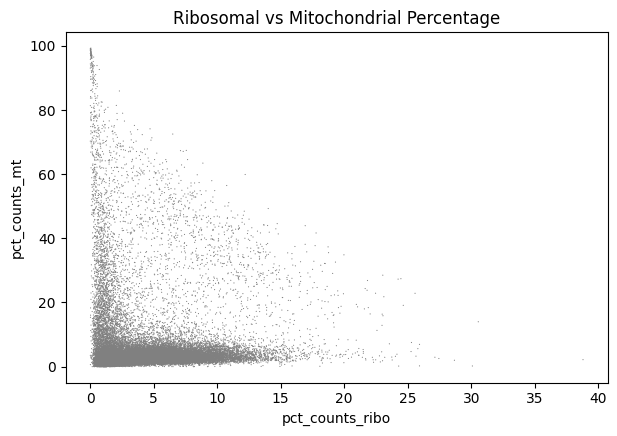

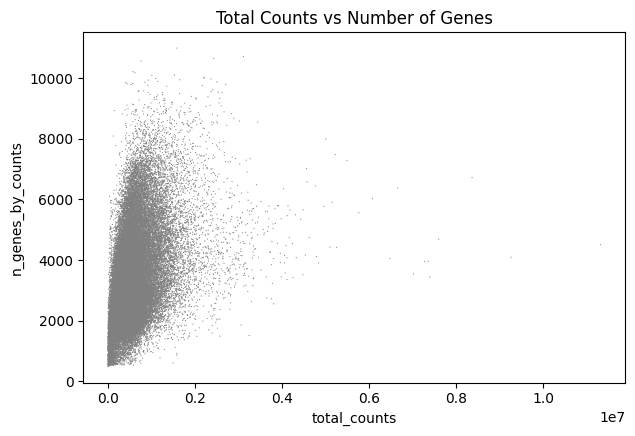

In [ ]:
# @markdown Plot further QC metrics
# Scatter plots
# total_counts == n_counts
sc.pl.scatter(adata_GE, x="total_counts", y="pct_counts_mt", title="Total Counts vs Mitochondrial Percentage", save="_" + dataset_name[:-1] + "_full_data_totalcounts_pctcountsmt.png")
sc.pl.scatter(adata_GE, x="total_counts", y="pct_counts_ribo", title="Total Counts vs Ribosomal Percentage", save="_" + dataset_name[:-1] + "_full_data_totalcounts_pctcountsribo.png")
sc.pl.scatter(adata_GE, x="pct_counts_ribo", y="pct_counts_mt", title="Ribosomal vs Mitochondrial Percentage", save="_" + dataset_name[:-1] + "_full_data_raw_pctcountsribo_pctcountsmt.png")
sc.pl.scatter(adata_GE, x="total_counts", y="n_genes_by_counts", title="Total Counts vs Number of Genes", save="_" + dataset_name[:-1] + "_full_data_totalcounts_ngenesbycounts.png")

In [ ]:
# @markdown **Filter cells by number of counts:** Cells with less than the count threshold are maintained:
total_counts_threshold = 2000000 # @param {type:"integer"}
adata_GE = adata_GE[adata_GE.obs.total_counts < total_counts_threshold, :]

print(f"Cells with less than {total_counts_threshold} counts are preserved yielding the AnnData object: \n {adata_GE}")

View of AnnData object with n_obs × n_vars = 43761 × 27348
    obs: 'FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden', 'cell_type', 'plate_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_id', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

In [ ]:
# @markdown **Filter cells by percentage of mitochondrial counts:** Cells with less than the percentage-threshold are maintained:
pct_counts_mt_threshold = 10 # @param {type:"slider", min:0, max:100, step:1}
adata_GE = adata_GE[adata_GE.obs.pct_counts_mt < pct_counts_mt_threshold, :]
print(f"Cells with less than {pct_counts_mt_threshold} % mitochondrial counts are preserved yielding the AnnData object: \n {adata_GE}")

View of AnnData object with n_obs × n_vars = 39394 × 27348
    obs: 'FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden', 'cell_type', 'plate_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_id', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

In [ ]:
# @markdown **Filter cells by percentage of ribosomal counts:** Cells with less than the percentage-threshold are maintained:

# Cells with less than 15% ribosomal counts are preserved
pct_counts_ribo_threshold = 15 # @param {type:"slider", min:0, max:100, step:1}
adata_GE = adata_GE[adata_GE.obs.pct_counts_ribo < pct_counts_ribo_threshold, :]
print(f"Cells with less than {pct_counts_ribo_threshold} % ribosomal counts are preserved yielding the AnnData object: \n {adata_GE}")

View of AnnData object with n_obs × n_vars = 39171 × 27348
    obs: 'FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden', 'cell_type', 'plate_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_id', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

In [ ]:
# @markdown **Minimum number of genes per cell:** Filter out genes with less than min_genes in a cell
min_genes = 200 # @param {type:"integer"}
sc.pp.filter_cells(adata_GE, min_genes=min_genes)

# @markdown **Minimum number of cells per gene:** Filter out genes with presence in less than min_cells
min_cells = 3 # @param {type:"integer"}
sc.pp.filter_genes(adata_GE, min_cells=min_cells)

print(f"The filtering yields the AnnData object: \n {adata_GE}")

/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_simple.py:176: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


AnnData object with n_obs × n_vars = 39171 × 27348
    obs: 'FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden', 'cell_type', 'plate_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_id', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

# Quality controls after filtering

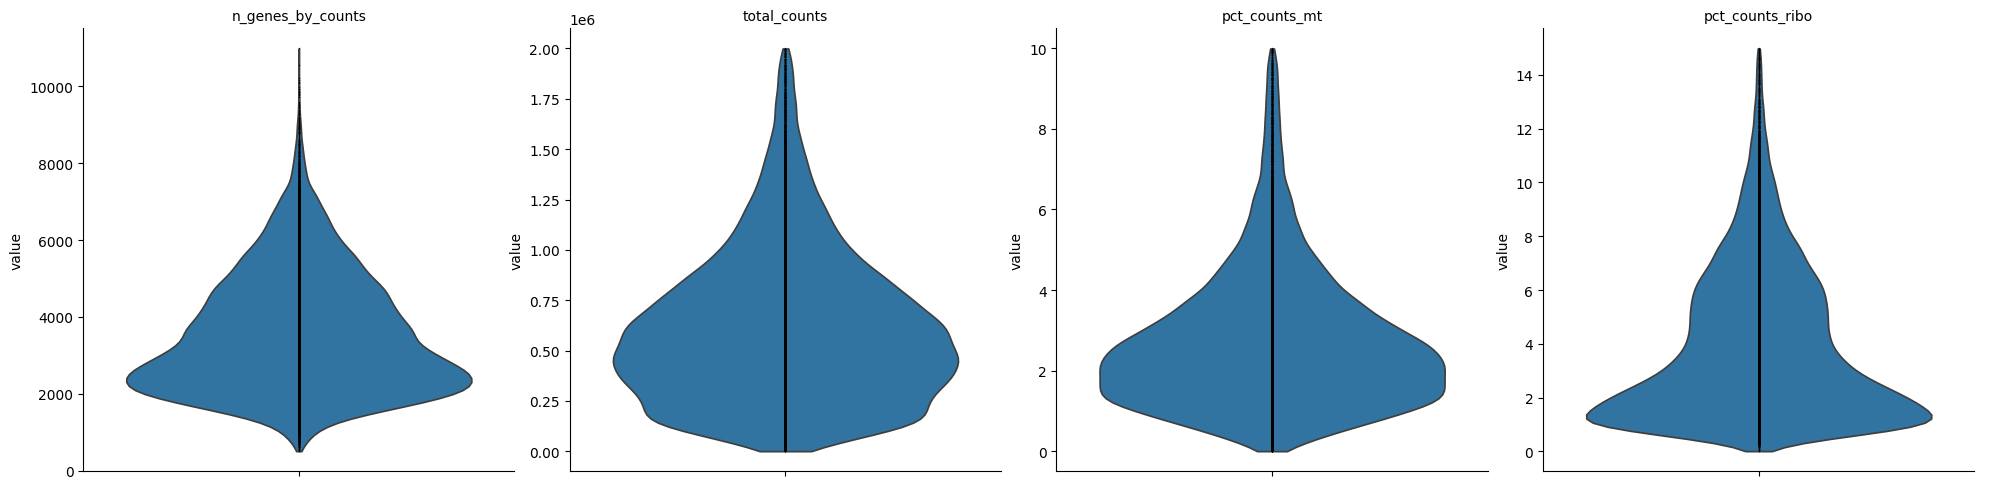

In [ ]:
# @markdown Re-run QC metrics to see the differences and save them as pre-processed
sc.pp.calculate_qc_metrics(
    adata_GE, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

sc.pl.violin(
    adata_GE,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo"],
    jitter=0,
    multi_panel=True,
    save="_" + dataset_name[:-1] + "_full_data_preprocessed.png"
)

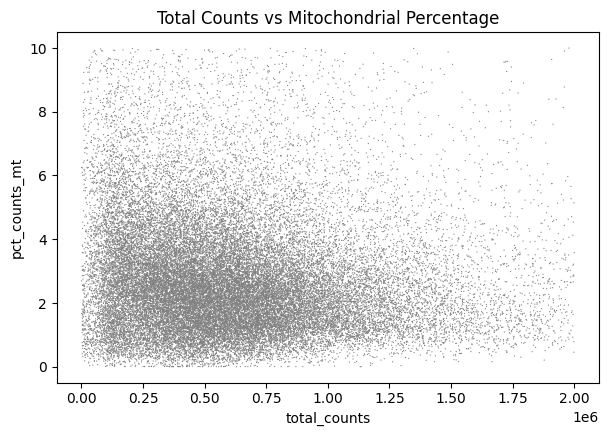

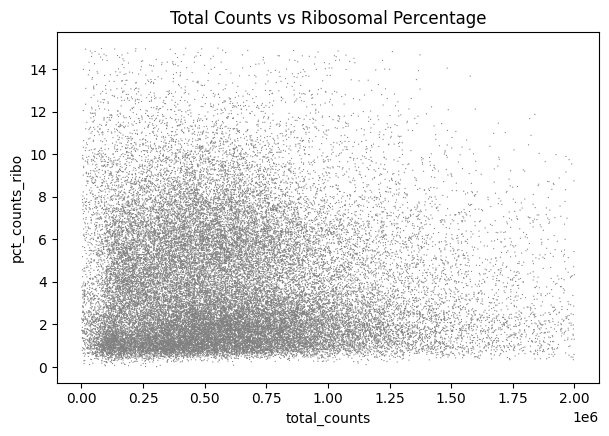

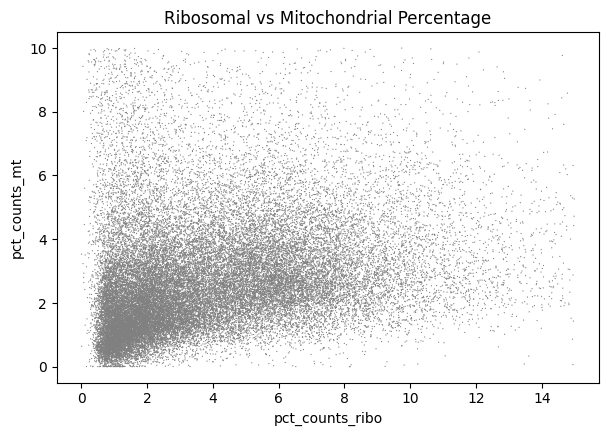

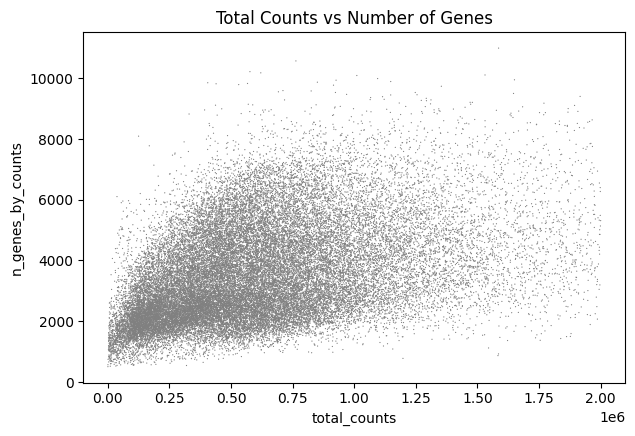

In [ ]:
# @markdown Re-run further QCs to see the differences to raw data after processing
#Scatter plots
# total_counts == n_counts
sc.pl.scatter(adata_GE, x="total_counts", y="pct_counts_mt", title="Total Counts vs Mitochondrial Percentage", save="_" + dataset_name[:-1] + "_full_data_preprocessed_totalcounts_pctcountsmt.png")
sc.pl.scatter(adata_GE, x="total_counts", y="pct_counts_ribo", title="Total Counts vs Ribosomal Percentage", save="_" + dataset_name[:-1] + "_full_data_preprocessed_totalcounts_pctcountsribo.png")
sc.pl.scatter(adata_GE, x="pct_counts_ribo", y="pct_counts_mt", title="Ribosomal vs Mitochondrial Percentage", save="_" + dataset_name[:-1] + "_full_data_preprocessed_pctcountsribo_pctcountsmt.png")
sc.pl.scatter(adata_GE, x="total_counts", y="n_genes_by_counts", title="Total Counts vs Number of Genes", save="_" + dataset_name[:-1] + "_full_data_preprocessed_totalcounts_ngenesbycounts.png")

In [ ]:
# @markdown Save count data to .layers["counts"]
adata_GE.layers["counts"] = adata_GE.X.copy()

print(f"After filtering and QCs, the AnnData object is: \n {adata_GE}")

# Save Anndata object
#adata_GE.write(path2dataset + "adata_GE_preClustAssess.h5ad")

# Determining number of highly variable genes through ClustAssess

ClustAssess is a tool to determine stable and single-cell clustering. Here it is used to determine a suitable number of highly variable genes (HVGs). Therefore, the dimensionality reduction and graph construction is evaluated for different sets of HVGs and most abundant genes (MVGs).

For further details of ClustAssess check out

[Shahsavari et al. (2022): ClustAssess: tools for assessing the robustness of single-cell clustering](https://www.biorxiv.org/content/10.1101/2022.01.31.478592v1.full)

and the Python implementation

https://github.com/Core-Bioinformatics/ClustAssessPy.

In [ ]:
# @markdown **Number of highly variable / most abundant genes:** Determine the number of highly variable / abundant genes
num_hvg = 5000 # @param {type:"integer"}

sc.pp.highly_variable_genes(adata_GE, flavor='seurat_v3', n_top_genes=num_hvg)

# Get highly variable genes ranked
highly_var_genes_sorted = adata_GE.var['highly_variable_rank'][~adata_GE.var['highly_variable_rank'].isna()].sort_values().index.to_numpy().tolist()

# Get most abundant genes ranked
most_abundant_genes_sorted = pd.Series(adata_GE.X.toarray().sum(axis=0), index=adata_GE.var_names).sort_values(ascending=False).head(num_hvg).index.tolist()


In [ ]:
# @markdown Normalise and log(1 + x) the gene expression count data if not already done so
sc.pp.normalize_total(adata_GE, target_sum=1e4) # Alternative: Normalizing to median total counts with target_sum=None, or normalising to CPM with target_sum=1e6
sc.pp.log1p(adata_GE)

print(f"After normalisation and log(1 + x) transformation, the AnnData object is: \n {adata_GE}")

/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.


## Dimensionality reduction

In [ ]:
# @markdown ClustAssess requires a scaling of the data before the PCA and the nearest neighbour graph is caluclated.
#Scale the data
sc.pp.scale(adata_GE) # I do not do this for the VAEs

# Get scaled data
scaled_data = adata_GE.to_df()

# PCA
sc.tl.pca(adata_GE, svd_solver='arpack')
pca_embs = adata_GE.obsm['X_pca']

# Nearest neighbour graph
sc.pp.neighbors(adata_GE, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata_GE)

print(f"Following AnnData object is used for ClustAssess: \n {adata_GE}")

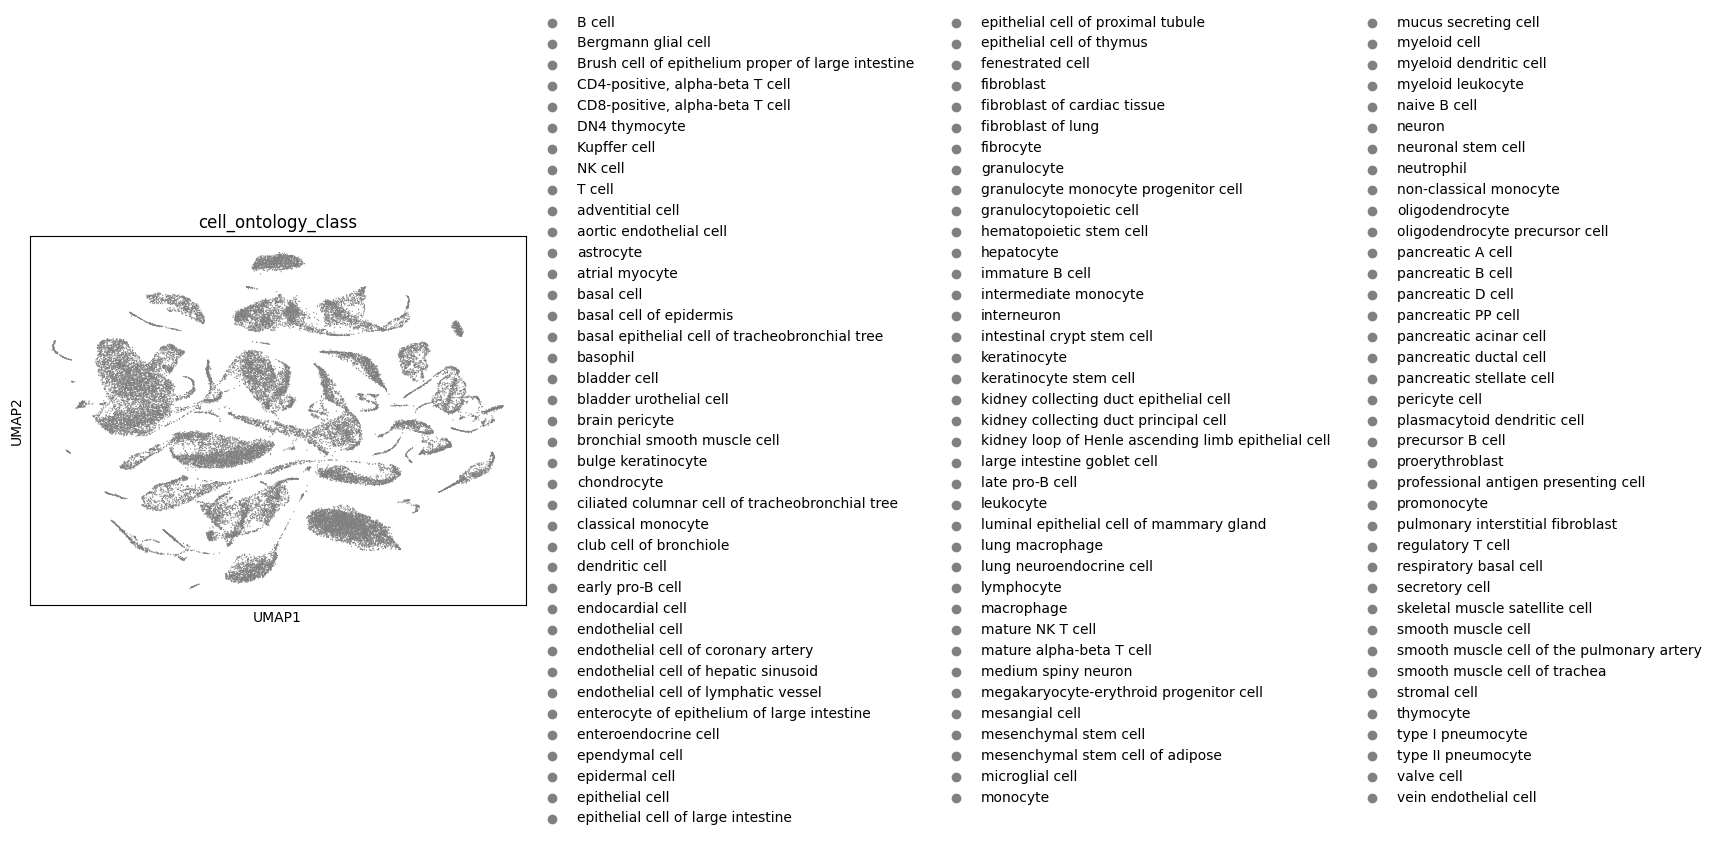

In [ ]:
# @markdown Show the UMAP colored by the cell type key
sc.pl.umap(adata_GE, color=settings["cell_type_key"])

In [ ]:
# @markdown **Feature stability:** Run the feature stability assessment on the HVGs across different sets of HVGs determined by the steps
steps = [1000, 2000, 3000, 4000, 5000] # @param

feature_stability_HV = ca.assess_feature_stability(
    data_matrix = scaled_data,
    feature_set = highly_var_genes_sorted,
    steps = steps,
    feature_type = 'HV',
    resolution = [0.3, 0.5, 0.7],
    n_repetitions=50,
    algorithm='leiden',
    ncores=4 # 8 cores result in crash due to system RAM exceeding 167.1GB
)

FutureWarnings (caused by ScanPy for Leiden) will be suppressed. Set show_warnings=True to see them.


/usr/local/lib/python3.12/dist-packages/ClustAssessPy/dim_reduction_assessment.py:200: UserWarning: Please ensure data matrix has rows as cells and columns as features.


In [ ]:
# @markdown **Feature stability:** Run the feature stability assessment on the MAGs across different sets of MAGs determined by the steps
steps = [1000, 2000, 3000, 4000, 5000] # @param

feature_stability_MA = ca.assess_feature_stability(
    data_matrix = scaled_data,
    feature_set = most_abundant_genes_sorted,
    steps = steps,
    feature_type = 'MA',
    resolution = [0.3, 0.5, 0.7],
    n_repetitions=50,
    algorithm='leiden',
    ncores=4
)

FutureWarnings (caused by ScanPy for Leiden) will be suppressed. Set show_warnings=True to see them.


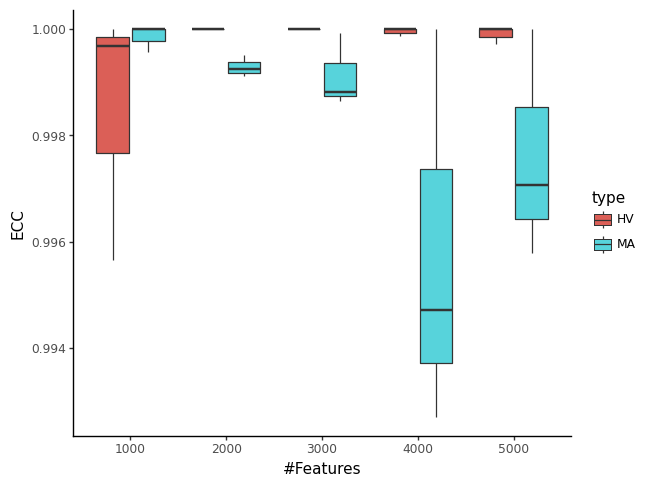

In [ ]:
# @markdown **Feature stability of dimensionality reduction:** Plot the feature stability of the dimensionality reduction assessed by the ECC score for the different steps of HVGs and MAGs defined by the steps variable.
ca.plot_feature_overall_stability_boxplot([feature_stability_HV, feature_stability_MA])

/usr/local/lib/python3.12/dist-packages/ClustAssessPy/plotting_functions.py:85: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


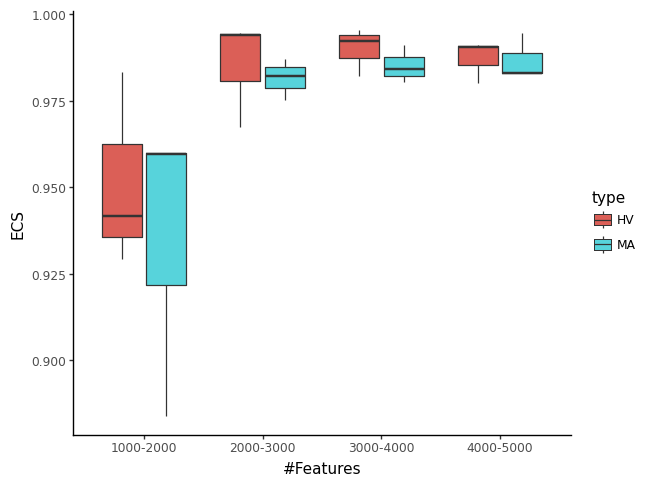

In [ ]:
# @markdown **Incremental feature stability of dimensionality reduction:** Plot the incremental feature stability of the dimensionality reduction assessed by the ECS score for the different steps of HVGs and MAGs defined by the steps variable.

ca.plot_feature_overall_stability_incremental([feature_stability_HV, feature_stability_MA])

For the Tabula Muris dataset we then chose 3000 HVGs as suitable.

## Graph construction

For completeness, we also run the nearest neighbour (NN) graph construction assessment although it is not necessary for the subsequent analysis.

In [ ]:
# @markdown **NN stability assessment of the Leiden algorithm:** Define the sequence of nearest neighbour to assess
nn_sequence = [5, 10, 15, 20, 25, 30] # @param

nn_stability_obj_leiden = ca.assess_nn_stability(
    pca_embs,
    n_neigh_sequence=nn_sequence,
    n_repetitions = 50,
    algorithm = 'leiden',
    graph_type = 2,
    ncores=4
)

FutureWarnings (caused by ScanPy for Leiden) will be suppressed. Set show_warnings=True to see them.


In [ ]:
# @markdown **NN stability assessment of the Leiden algorithm:** Define the sequence of nearest neighbour to assess

# Required to do umap assessment in parallel. This is a requirement of the UMAP and Numba libraries.
from numba import config
config.THREADING_LAYER = 'tbb'
!numba -s | grep TBB

nn_stability_obj_leiden_umap = ca.assess_nn_stability(
    pca_embs,
    n_neigh_sequence=nn_sequence,
    graph_reduction_type = "UMAP",
    n_repetitions = 50,
    algorithm = 'leiden',
    graph_type = 2,
    ncores=4
)

FutureWarnings (caused by ScanPy for Leiden) will be suppressed. Set show_warnings=True to see them.


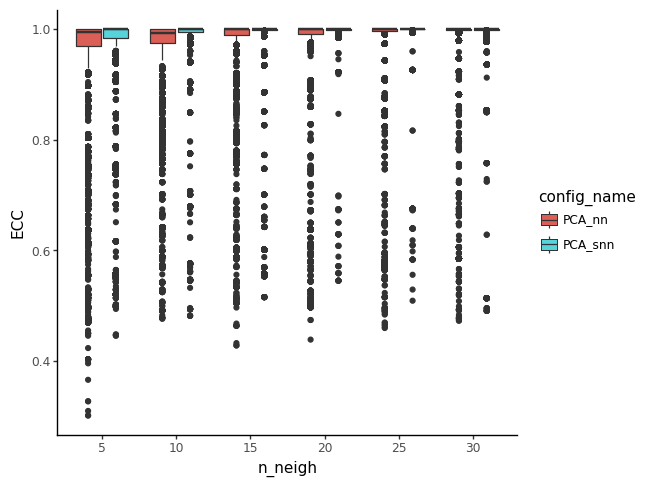

In [ ]:
# @markdown Plot the NN stability assessment of the Leiden algorithm
ca.plot_n_neigh_ecs(nn_stability_obj_leiden)

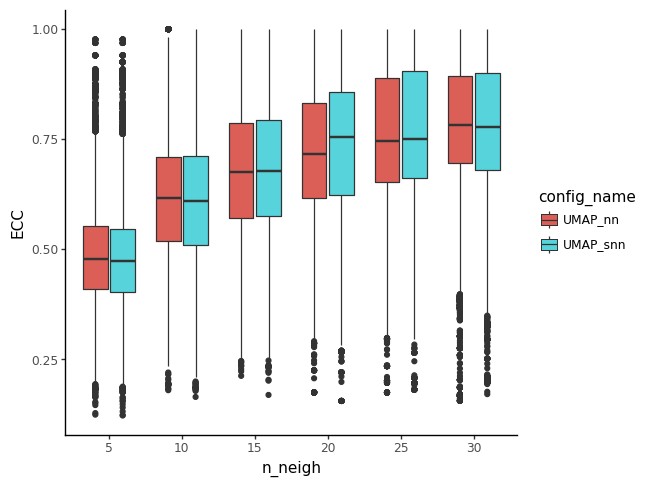

In [ ]:
# @markdown Plot the NN stability assessment of the UMAP
ca.plot_n_neigh_ecs(nn_stability_obj_leiden_umap)

## Load generated plots and assemble them for figure panel

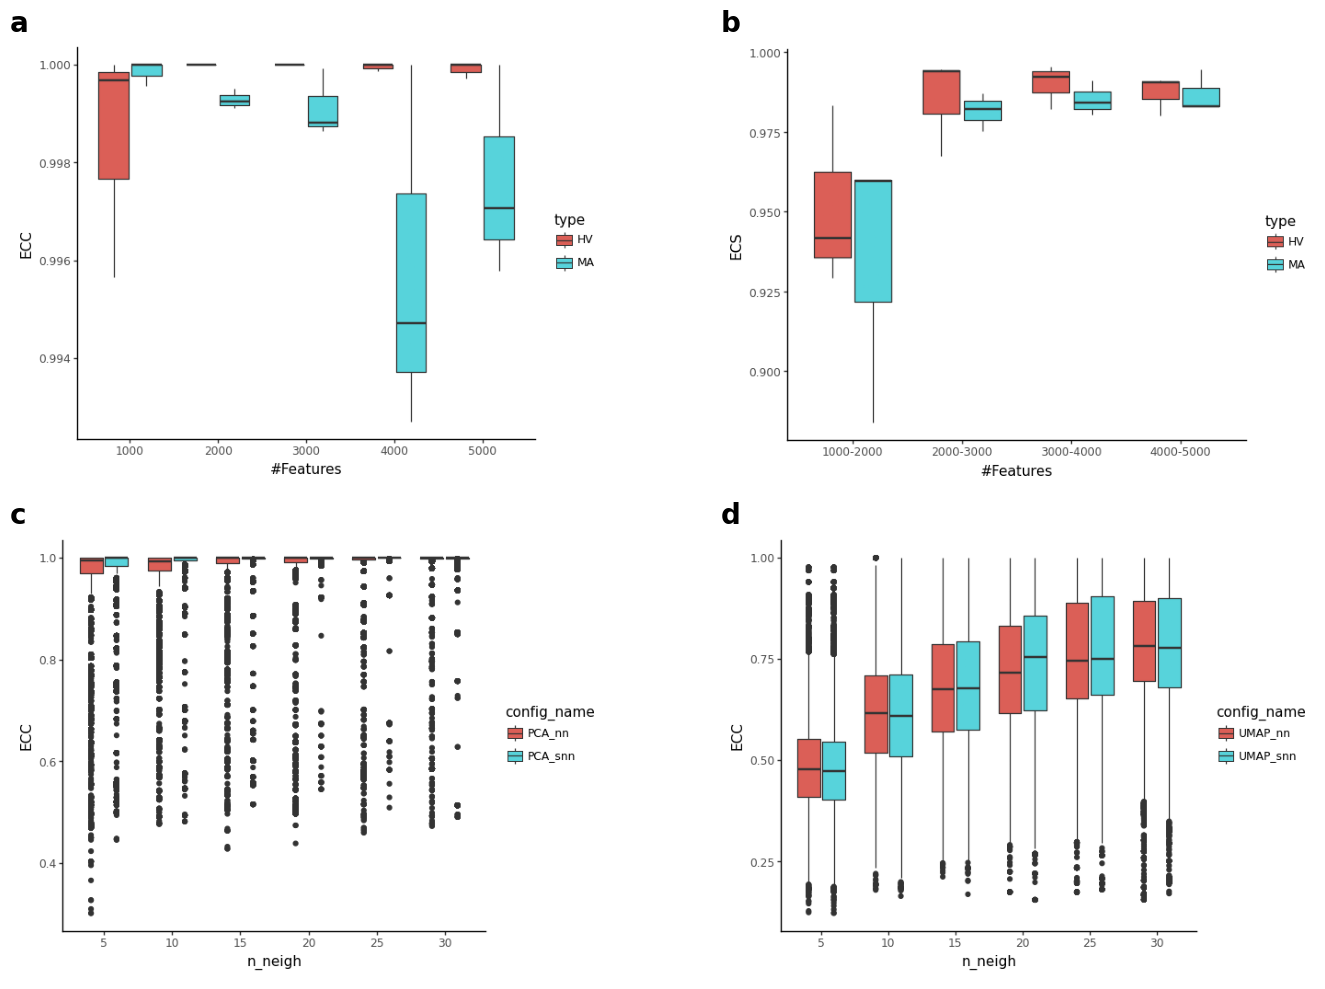

In [ ]:
import matplotlib.image as mpimg

# @markdown **ClustAssess results:** Assemble the ClustAssess the results in a figure panel and save it:

save_fig=True # @param {type:"boolean"}

# Path to plots
ca_feature_stability_plot = "./figures/" + settings["dataset_name"] + "/tabulaMuris_ClustAssess_FeatureStability.png"
ca_feature_stability_incremental_plot = "./figures/" + settings["dataset_name"] + "/tabulaMuris_ClustAssess_FeatureStabilityIncremental.png"
ca_nn_stability_leiden_plot = "./figures/" + settings["dataset_name"] + "/tabulaMuris_ClustAssess_NN_Leiden_ECC.png"
ca_nn_stability_leiden_umap_plot = "./figures/" + settings["dataset_name"] + "/tabulaMuris_ClustAssess_NN_Leiden_UMAP_ECC.png"

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))

plots = [
    (ca_feature_stability_plot, "a"), # Feature Stability
    (ca_feature_stability_incremental_plot, "b"), # Feature Stability (Incremental)
    (ca_nn_stability_leiden_plot, "c"), # NN Stability (Leiden)
    (ca_nn_stability_leiden_umap_plot, "d") # NN Stability (Leiden UMAP)
]

for ax, (img_path, title) in zip(axs.flat, plots):
    try:
        img = mpimg.imread(img_path)
        ax.imshow(img)
        ax.set_title(title, loc='left', fontsize=20, fontweight='bold')
        ax.axis('off')  # Hide X and Y axes for a cleaner look
    except FileNotFoundError:
        ax.text(0.5, 0.5, f"Image not found:\n{img_path}",
                ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')

plt.tight_layout()

if save_fig:
    plt.savefig("./figures/" + settings["dataset_name"] + "/clustassess_plots.pdf", dpi=300)

plt.show()

# Normalisation and log(1+x)-transformation

In [ ]:
# @markdown Normalise and log(1 + x) transform the gene expression counts
# Normalizing to median total counts
sc.pp.normalize_total(adata_GE)
# Logarithmize the data
sc.pp.log1p(adata_GE)

print(f"After normalisation and log(1 + x) transformation, the AnnData object is: \n {adata_GE}")

# Highly variable genes selection

In [ ]:
# @markdown The following AnnData object is used for the highly variable genes selection:
print(adata_GE)

AnnData object with n_obs × n_vars = 39171 × 27348
    obs: 'FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden', 'cell_type', 'plate_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_id', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'log1p'
    layers: 'counts'

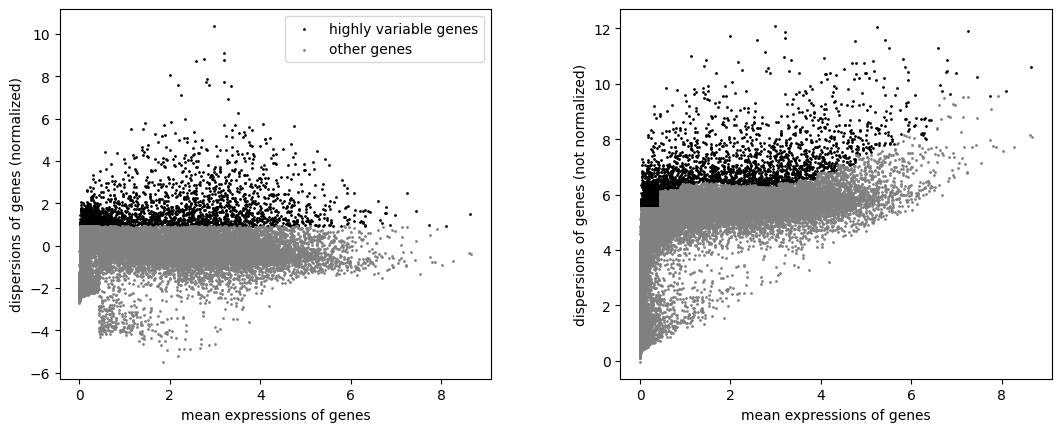

In [ ]:
# @markdown **Number of highly variable genes (HVGs):** Choose the number of HVGs after the ClustAssess analysis (3000 HVGs is used for Tabula Muris)
num_hvg = 3000 # @param {type:"integer"}
sc.pp.highly_variable_genes(adata_GE, n_top_genes=num_hvg)

sc.pl.highly_variable_genes(adata_GE, save="_" + dataset_name[:-1] + "_full_data_preprocessed_hvgs.png")

# Extract gene expression matrix of shape n_obs x n_hvg
hvg_annotation = adata_GE.var["highly_variable"].values

## Dimensionality reductions based on HVGs


In [ ]:
# @markdown **PCA and UMAP:** Calculate a PCA and display the dataset as UMAP. The highly variable genes are used for the PCA calculation
# PCA
sc.tl.pca(adata_GE, use_highly_variable=True)

# Nearest neighbor graph and UMAP calculation
sc.pp.neighbors(adata_GE)     #, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata_GE)

# Show UMAP plot colored by cell ontology class
sc.pl.umap(adata_GE, color=settings["cell_type_key"])

/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None


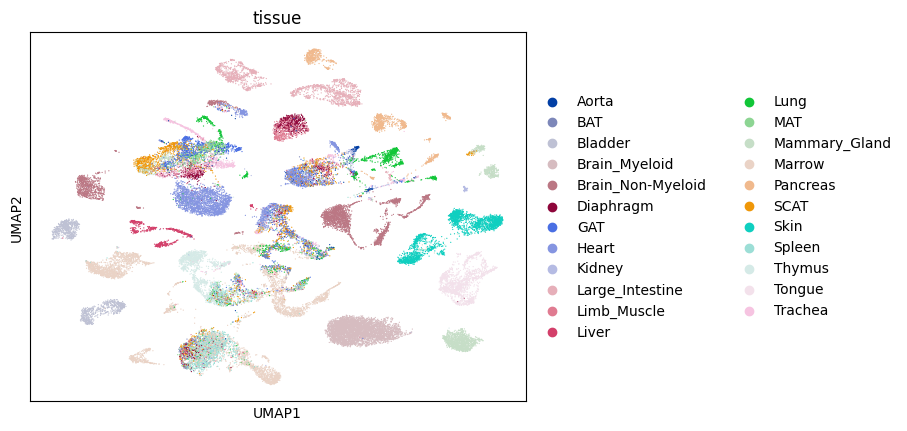

# Save full gene expression dataset

In [ ]:
# @markdown Save the pre-processed gene expression data and a npy file containing the HVG annotation
save_full_dataset = True # @param {type:"boolean"}

if save_full_dataset:
    # Save highly variable genes
    np.save(path2dataset + "full_hvg_annotation.npy", hvg_annotation)

    # Save pre-processed gene expression Anndata object as .h5ad-file
    adata_GE.write_h5ad(path2dataset + "adata_GE_full_preprocessed.h5ad")

    print(f"Following AnnData object is saved: \n {adata_GE}")

# Pre-process transcript usage data

After having processed the gene expression data, the transcript usage data capturing the alternative splicing profiles for each cell are processed accordingly.

In [ ]:
# @markdown Load pre-processed gene expression Anndata object as .h5ad-file and the highly variable genes
adata_GE = ad.read_h5ad(path2dataset + "adata_GE_full_preprocessed.h5ad")

# Load highly variable genes
hvg_annotation = np.load(path2dataset + "full_3000_hvg_annotation.npy")

print(f"Following AnnData object is loaded: \n {adata_GE}")

In [ ]:
# @markdown **Load transcript usage data:** The previously specified Anndata object splicing_file containing the alternative splicing profiles is loaded. The file is annotated with the according gene_annotation file with must be in the ./data directory. The gene annotation file has been specified in the settings dictionary

path2geneannotation = "./data/" + settings["gene_annotation"]

from crecerelle.utils import add_gene_annotation, group_introns

# Load transcript usage data
adata_TU = ad.read_h5ad(path2dataset + splicing_file)

# Include gene annotation and intron groups
adata_TU.var = adata_TU.var[["chromosome", "start", "end", "strand", "annotated"]]
adata_TU.var.end -= 1
adata_TU.var.index = adata_TU.var.chromosome.astype(str) + ":" + adata_TU.var.start.astype(str) + "-" \
                  + adata_TU.var.end.astype(str)
adata_TU = add_gene_annotation(adata_TU, gene_annotation)
adata_TU = group_introns(adata_TU, by="three_prime")

print(f"Following AnnData object has been annotated: \n {adata_TU}")

/content/drive/MyDrive/scASpred/scquint_data.py:44: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.


Filtering to introns associated to 1 and only 1 gene.


/content/drive/MyDrive/scASpred/scquint_data.py:129: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.


Filtering singletons.
Filtering intron groups associated with more than 1 gene.


/usr/local/lib/python3.12/dist-packages/pandas/core/generic.py:6329: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.


In [ ]:
# @markdown **Filter to HVGs:** Remove all genes from transcript usage data that are not HVGs
adata_TU = remove_cell_genes(adata_GE, adata_TU) # Results in 39,171 cells x 2319 introns (600 HVGs)

print(f"The removal of non-HVGs from the transcript usage data yields the following AnnData object: \n {adata_TU}")

Number of removed genes: 7037
Number of highly variable genes in transcript usage data: 600


View of AnnData object with n_obs × n_vars = 39171 × 2319
    obs: 'FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden', 'cell_type', 'plate_id'
    var: 'chromosome', 'start', 'end', 'strand', 'annotated', 'gene_id_start', 'gene_id_end', 'n_genes', 'gene_id', 'gene_name', 'intron_group', 'intron_group_size', 'n_genes_per_intron_group'

In [ ]:
# @markdown **PSI score:** Calculate the PSI score for transcript usage data and add it to .layers["psi"]
psi_matrix = compute_psi(adata_TU).astype(np.float32)

if adata_TU.X.shape == psi_matrix.shape:
    adata_TU.layers["psi"] = psi_matrix

# @markdown **Exon junction (intron) counts:** The exon junction counts are saved to .layers["counts"]
# Save counts to layer
adata_TU.layers["counts"] = adata_TU.X.copy()

# @markdown The exon junction counts are similar to gene expression data normalised and log(1 + x) transformed
# Normalise to median counts
sc.pp.normalize_total(adata_TU)

# Logarithmize the data -> now log(1 + x) transformed normalised counts (intron levels)
sc.pp.log1p(adata_TU)

# Results in 39,171 cells x 2319 introns (600 HVGs)
print(f"Following AnnData object is used for the analysis: \n {adata_TU}")

/usr/local/lib/python3.12/dist-packages/crecerelle/utils.py:153: RuntimeWarning: invalid value encountered in divide
/tmp/ipython-input-3127147783.py:5: ImplicitModificationWarning: Setting element `.layers['psi']` of view, initializing view as actual.


AnnData object with n_obs × n_vars = 39171 × 2319
    obs: 'FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden', 'cell_type', 'plate_id'
    var: 'chromosome', 'start', 'end', 'strand', 'annotated', 'gene_id_start', 'gene_id_end', 'n_genes', 'gene_id', 'gene_name', 'intron_group', 'intron_group_size', 'n_genes_per_intron_group'
    uns: 'log1p'
    layers: 'psi', 'counts'

In [ ]:
# @markdown Save pre-processed transcrip usage Anndata object of transcript usage data as .h5ad-file
save_full_dataset = True # @param {type:"boolean"}

if save_full_dataset:
    adata_TU.write_h5ad(path2data + "adata_TU_full_preprocessed.h5ad")

# Split gene expression and transcript usage data

The pre-processed gene expression and transcript usage data are split into training, validation, and test set for *Crecerelle*.

In [ ]:
# @markdown Load the pre-processed gene expression and transcript usage AnnData objects.

# Load pre-processed gene expression Anndata object (.h5ad-file)
adata_GE = ad.read_h5ad(path2data + "adata_GE_full_preprocessed.h5ad")

# Load pre-processed transcript usage Anndata object (.h5ad-file)
adata_TU = ad.read_h5ad(path2data + "adata_TU_full_preprocessed.h5ad")

print(f"Following AnnData object containing pre-processed gene expression data is loaded: \n {adata_GE}")
print(f"Following AnnData object containing pre-processed transcript usage data is loaded: \n {adata_TU}")

AnnData object with n_obs × n_vars = 39171 × 27348
    obs: 'FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden', 'cell_type', 'plate_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_id', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cell_ontology_class_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'tissue_colors', 'u

AnnData object with n_obs × n_vars = 39171 × 2319
    obs: 'FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden', 'cell_type', 'plate_id'
    var: 'chromosome', 'start', 'end', 'strand', 'annotated', 'gene_id_start', 'gene_id_end', 'n_genes', 'gene_id', 'gene_name', 'intron_group', 'intron_group_size', 'n_genes_per_intron_group'
    uns: 'log1p'
    layers: 'counts', 'psi'

In [ ]:
# @markdown Split adata into training, validation, and test dataset
adata = (adata_GE, adata_TU)
train_dataset, val_dataset, test_dataset = split_adata_dataset(adata)

In [ ]:
# @markdown Check if dataset splitting was successful i.e. no data leakage between files is present
train_cells = train_dataset[0].obs_names.to_numpy()
val_cells = val_dataset[0].obs_names.to_numpy()
test_cells = test_dataset[0].obs_names.to_numpy()

print(f"Data leakage between training and validation set: {np.any(np.isin(train_cells, val_cells))}")
print(f"Data leakage between training and test set: {np.any(np.isin(train_cells, test_cells))}")
print(f"Data leakage between validation and test set: {np.any(np.isin(val_cells, test_cells))}")

Data leakage between training and validation set: False
Data leakage between training and test set: False
Data leakage between validation and test set: False


In [ ]:
# @markdown Save training, validation, and test datasets as .h5ad files. The data are named e.g. "adata_GE_"+ str(num_hvg)+ "_train.h5ad", or "adata_TU_"+ str(num_hvg)+ "_val.h5ad"
if save_splitted_dataset:
    train_dataset[0].write_h5ad(path2data + "adata_GE_" + str(settings["num_hvg"]) + "_train.h5ad")
    train_dataset[1].write_h5ad(path2data + "adata_TU_" + str(settings["num_hvg"]) + "_train.h5ad")
    val_dataset[0].write_h5ad(path2data + "adata_GE_" + str(settings["num_hvg"]) + "_val.h5ad")
    val_dataset[1].write_h5ad(path2data + "adata_TU_" + str(settings["num_hvg"]) + "_val.h5ad")
    test_dataset[0].write_h5ad(path2data + "adata_GE_" + str(settings["num_hvg"]) + "_test.h5ad")
    test_dataset[1].write_h5ad(path2data + "adata_TU_" + str(settings["num_hvg"]) + "_test.h5ad")

print(f"Splitted data have been saved")